In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch

# Install torch_geometric and its dependencies
!pip install torch_geometric torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-{torch.__version__}.html

import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GATConv

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

Looking in links: https://data.pyg.org/whl/torch-2.11.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 681.6/681.6 kB 17.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 48.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.8/827.8 kB 40.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.2 MB/s eta 0:00:00
  Created wheel for torch_spline_conv: filename=torch_spline_conv-1.2.2-cp312-cp312-linux_x86_64.whl size=303352 sha256=ed05e268338fd56003e1c1ddc35610833cf29fd0d2f8179668e8a3c8f7c63be3
  Stored in directory: /root/.cache/pip/wheels/54/7a/2e/46a729dc0aad2da1a908b0d2ac86ab127d73e6b4310a945d07
Successfully built torch_spline_conv


In [4]:
graph = torch.load(
    "/content/real graph.pt",
    weights_only=False,
    map_location="cpu"
)

print(graph)

Data(x=[1000, 152], edge_index=[2, 8054], y=[1000], edge_weight=[8054], train_mask=[1000], val_mask=[1000], test_mask=[1000])


In [5]:
class OriginalGAT(nn.Module):

    def __init__(self, input_dim, hidden_dim=32, num_classes=3):
        super().__init__()

        self.gat1 = GATConv(
            input_dim,
            hidden_dim,
            heads=4,
            dropout=0.3
        )

        self.gat2 = GATConv(
            hidden_dim * 4,
            hidden_dim,
            heads=1,
            dropout=0.3
        )

        self.classifier = nn.Linear(
            hidden_dim,
            num_classes
        )

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index

        x = self.gat1(x, edge_index)
        x = F.elu(x)

        x = self.gat2(x, edge_index)
        x = F.elu(x)

        x = self.classifier(x)

        return x

In [6]:
model = OriginalGAT(
    input_dim=graph.x.shape[1],
    hidden_dim=32,
    num_classes=3
)

print(model)

OriginalGAT(
  (gat1): GATConv(152, 32, heads=4)
  (gat2): GATConv(128, 32, heads=1)
  (classifier): Linear(in_features=32, out_features=3, bias=True)
)


In [7]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = OriginalGAT(
    input_dim=graph.x.shape[1],
    hidden_dim=32,
    num_classes=3
).to(device)

graph = graph.to(device)

print("Model created successfully.")

Model created successfully.


In [8]:
model = OriginalGAT(
    input_dim=graph.x.shape[1],
    hidden_dim=32,
    num_classes=3
)

print(model)

OriginalGAT(
  (gat1): GATConv(152, 32, heads=4)
  (gat2): GATConv(128, 32, heads=1)
  (classifier): Linear(in_features=32, out_features=3, bias=True)
)


In [9]:
model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/Original_GAT_New Real.pth",
        map_location=device
    )
)

model.eval()

print("Trained model loaded successfully.")

Trained model loaded successfully.


In [10]:
with torch.no_grad():

    outputs = model(graph)

    predictions = outputs.argmax(dim=1)

print("Predictions generated successfully.")

Predictions generated successfully.


In [11]:
y_true = graph.y[graph.test_mask].cpu().numpy()

y_pred = predictions[graph.test_mask].cpu().numpy()

print("Number of test samples:", len(y_true))

Number of test samples: 150


In [12]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.7733
Precision: 0.7738
Recall   : 0.7733
F1-score : 0.7724


In [13]:
print(classification_report(
    y_true,
    y_pred,
    digits=4
))

              precision    recall  f1-score   support

           0     0.7674    0.8684    0.8148        38
           1     0.7887    0.7467    0.7671        75
           2     0.7500    0.7297    0.7397        37

    accuracy                         0.7733       150
   macro avg     0.7687    0.7816    0.7739       150
weighted avg     0.7738    0.7733    0.7724       150



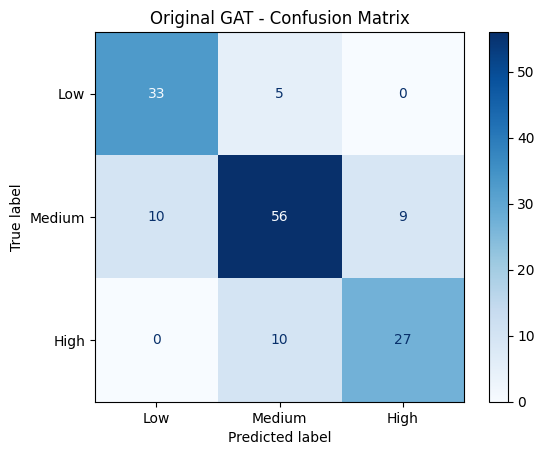

In [14]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Low",
        "Medium",
        "High"
    ]
)

disp.plot(cmap="Blues")

plt.title("Original GAT - Confusion Matrix")

plt.show()

In [15]:
results = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

for metric, value in results.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.7733
Precision: 0.7738
Recall: 0.7733
F1 Score: 0.7724


In [16]:
print(graph)

Data(x=[1000, 152], edge_index=[2, 8054], y=[1000], edge_weight=[8054], train_mask=[1000], val_mask=[1000], test_mask=[1000])


In [17]:
print("Node features:", graph.x.shape)
print("Edges:", graph.edge_index.shape)
print("Labels:", graph.y.shape)

Node features: torch.Size([1000, 152])
Edges: torch.Size([2, 8054])
Labels: torch.Size([1000])


In [18]:
print(torch.bincount(graph.y))

tensor([250, 500, 250])


In [19]:
print("Train:", graph.train_mask.sum().item())
print("Validation:", graph.val_mask.sum().item())
print("Test:", graph.test_mask.sum().item())

Train: 700
Validation: 150
Test: 150


In [20]:
from sklearn.metrics import classification_report

model.eval()

with torch.no_grad():
    out = model(graph)
    pred = out.argmax(dim=1)

y_true = graph.y[graph.test_mask].cpu().numpy()
y_pred = pred[graph.test_mask].cpu().numpy()

print(classification_report(
    y_true,
    y_pred,
    digits=4
))

              precision    recall  f1-score   support

           0     0.7674    0.8684    0.8148        38
           1     0.7887    0.7467    0.7671        75
           2     0.7500    0.7297    0.7397        37

    accuracy                         0.7733       150
   macro avg     0.7687    0.7816    0.7739       150
weighted avg     0.7738    0.7733    0.7724       150



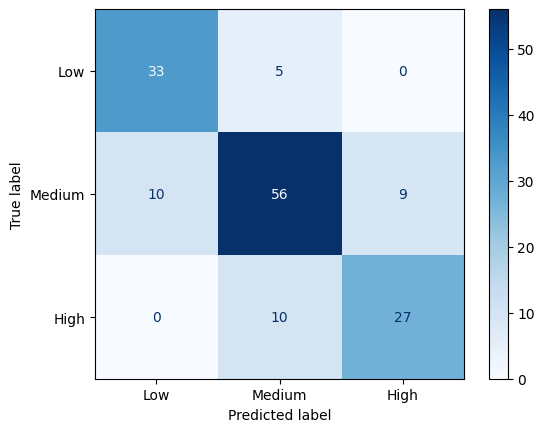

In [21]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low","Medium","High"]
)

disp.plot(cmap="Blues")
plt.show()

In [22]:
from sklearn.metrics import classification_report

model.eval()

with torch.no_grad():
    out = model(graph)
    pred = out.argmax(dim=1)

y_true = graph.y[graph.test_mask].cpu().numpy()
y_pred = pred[graph.test_mask].cpu().numpy()

print(classification_report(
    y_true,
    y_pred,
    digits=4
))

              precision    recall  f1-score   support

           0     0.7674    0.8684    0.8148        38
           1     0.7887    0.7467    0.7671        75
           2     0.7500    0.7297    0.7397        37

    accuracy                         0.7733       150
   macro avg     0.7687    0.7816    0.7739       150
weighted avg     0.7738    0.7733    0.7724       150

